<a href="https://www.kaggle.com/code/lucashmateo/linkedin-job-postings-analysis?scriptVersionId=304118167" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# LinkedIn Job Postings Analysis (2023–2024)

This notebook analyzes over 123,000 job postings scraped from LinkedIn, covering companies, industries, required skills, benefits, and salary data. The goal is to surface actionable patterns in the U.S. job market and build a predictive model for annual salary estimation.

## Problem Context

LinkedIn is the largest professional network in the world, and its job marketplace reflects real-time demand across industries, functions, and experience levels. This dataset captures the full anatomy of a job posting — from the hiring company's size and sector to the specific skills required and the compensation offered. Understanding these dynamics has practical value for job seekers calibrating their positioning, recruiters benchmarking compensation, and analysts mapping labor market trends.

The dataset is relational: eleven files linked by `job_id` and `company_id`. The analysis integrates these sources to answer questions that no single file can address alone.

## Objectives

1. Characterize the job posting landscape: volume by industry, work type, experience level, and company size
2. Identify the most in-demand skills overall and by industry segment
3. Analyze salary distributions across industries, work types, and experience levels
4. Examine benefit offerings and their relationship to compensation levels
5. Predict annual salary using structured job and company features

## Imports

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

## Data Loading

In [79]:
BASE = '/kaggle/input/datasets/arshkon/linkedin-job-postings'

postings           = pd.read_csv(f'{BASE}/postings.csv', low_memory=False)
companies          = pd.read_csv(f'{BASE}/companies/companies.csv', low_memory=False)
company_industries = pd.read_csv(f'{BASE}/companies/company_industries.csv')
employee_counts    = pd.read_csv(f'{BASE}/companies/employee_counts.csv')
industries         = pd.read_csv(f'{BASE}/mappings/industries.csv')
skills             = pd.read_csv(f'{BASE}/mappings/skills.csv')
benefits           = pd.read_csv(f'{BASE}/jobs/benefits.csv')
job_skills         = pd.read_csv(f'{BASE}/jobs/job_skills.csv')
job_industries     = pd.read_csv(f'{BASE}/jobs/job_industries.csv')
salaries           = pd.read_csv(f'{BASE}/jobs/salaries.csv')

print('postings:          ', postings.shape)
print('companies:         ', companies.shape)
print('employee_counts:   ', employee_counts.shape)
print('industries:        ', industries.shape)
print('skills:            ', skills.shape)
print('benefits:          ', benefits.shape)
print('job_skills:        ', job_skills.shape)
print('job_industries:    ', job_industries.shape)
print('salaries:          ', salaries.shape)

postings:           (123849, 31)
companies:          (24473, 10)
employee_counts:    (35787, 4)
industries:         (422, 2)
skills:             (35, 2)
benefits:           (67943, 3)
job_skills:         (213768, 2)
job_industries:     (164808, 2)
salaries:           (40785, 8)


## Exploration

### 1. Postings Overview

In [80]:
print(f'Total postings:    {len(postings):,}')
print(f'Unique companies:  {postings["company_id"].nunique():,}')
print()
null_pct = (postings.isnull().sum() / len(postings) * 100).sort_values(ascending=False)
print('Null rates (%):')
print(null_pct[null_pct > 0].round(1).to_string())

Total postings:    123,849
Unique companies:  24,474

Null rates (%):
closed_time                  99.10
skills_desc                  98.00
med_salary                   94.90
remote_allowed               87.70
applies                      81.20
min_salary                   75.90
max_salary                   75.90
currency                     70.90
compensation_type            70.90
pay_period                   70.90
normalized_salary            70.90
posting_domain               32.30
application_url              29.60
formatted_experience_level   23.70
fips                         22.10
zip_code                     16.90
company_name                  1.40
company_id                    1.40
views                         1.40
description                   0.00


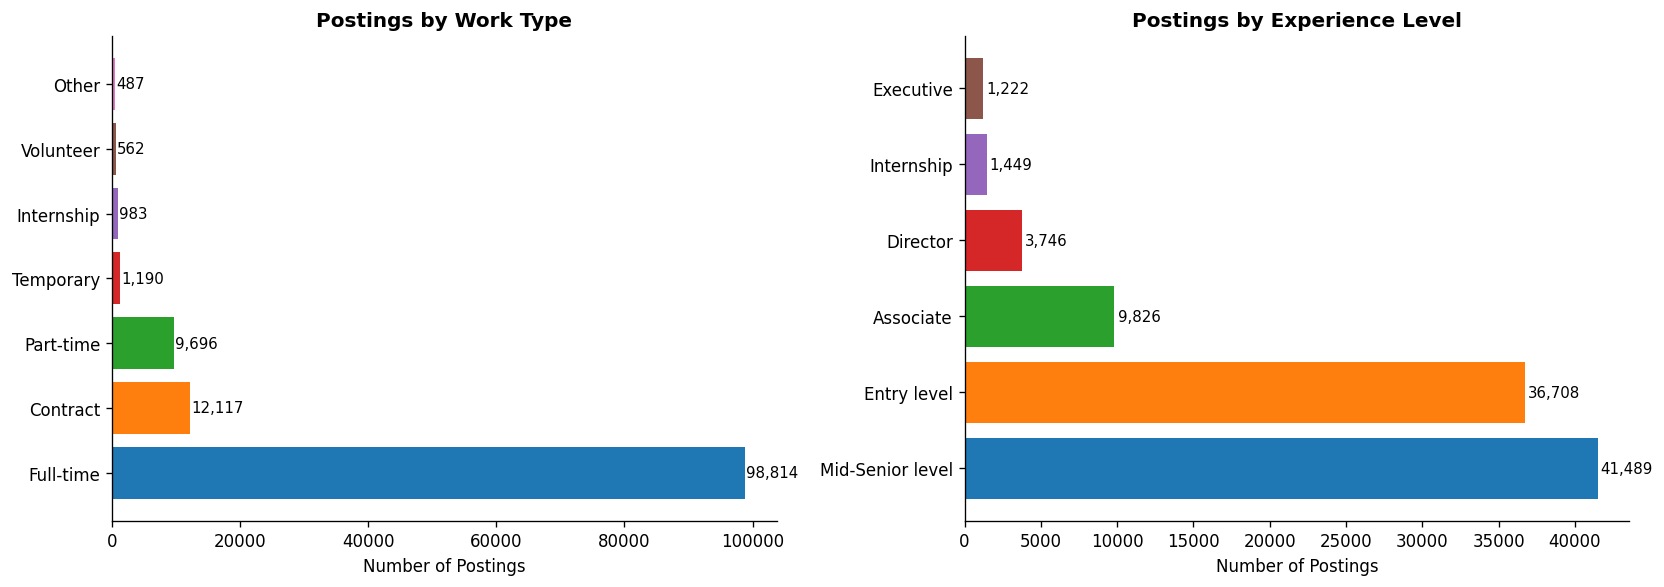

In [81]:
# Work type and experience level distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wt = postings['formatted_work_type'].value_counts()
axes[0].barh(wt.index, wt.values, color=sns.color_palette('tab10', len(wt)))
axes[0].set_title('Postings by Work Type', fontweight='bold')
axes[0].set_xlabel('Number of Postings')
for i, v in enumerate(wt.values):
    axes[0].text(v + 200, i, f'{v:,}', va='center', fontsize=9)

el = postings['formatted_experience_level'].value_counts()
axes[1].barh(el.index, el.values, color=sns.color_palette('tab10', len(el)))
axes[1].set_title('Postings by Experience Level', fontweight='bold')
axes[1].set_xlabel('Number of Postings')
for i, v in enumerate(el.values):
    axes[1].text(v + 200, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Work Type & Experience Level**

Full-time postings dominate the market with over 100,000 listings, but the split between experience levels is more balanced — Mid-Senior level leads, followed by Associate and Entry level. The near-absence of Executive postings on LinkedIn reflects how senior hiring is typically handled through retained search and direct referrals, not public job boards. For candidates, the data confirms that LinkedIn is most effective at the mid-career tier.

### 2. Top Industries by Posting Volume

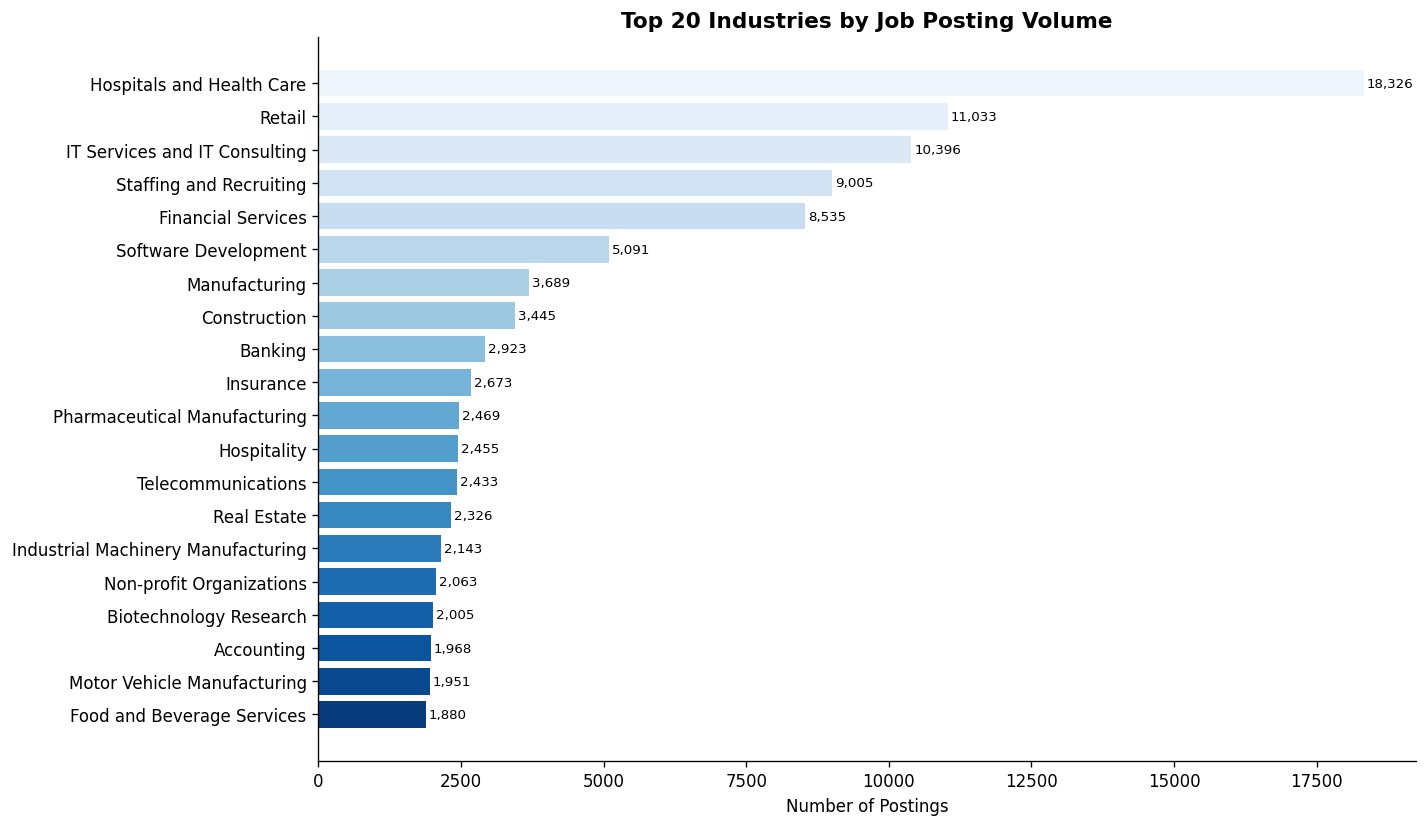

In [82]:
job_ind_named = job_industries.merge(industries, on='industry_id', how='left')

top_industries = (
    job_ind_named.groupby('industry_name')['job_id']
    .count()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_industries.index[::-1], top_industries.values[::-1],
               color=sns.color_palette('Blues_r', 20))
ax.set_title('Top 20 Industries by Job Posting Volume', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Postings')
for bar, val in zip(bars, top_industries.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Industry Concentration**

Staffing and recruiting firms account for a disproportionate share of postings — a pattern common to LinkedIn datasets, since agencies post on behalf of multiple clients. Technology and IT Services follow closely. This means raw industry counts overrepresent intermediaries and underrepresent end-employers. Analysts interpreting demand signals should weight direct employer postings more heavily than aggregate counts.

### 3. Company Size Distribution

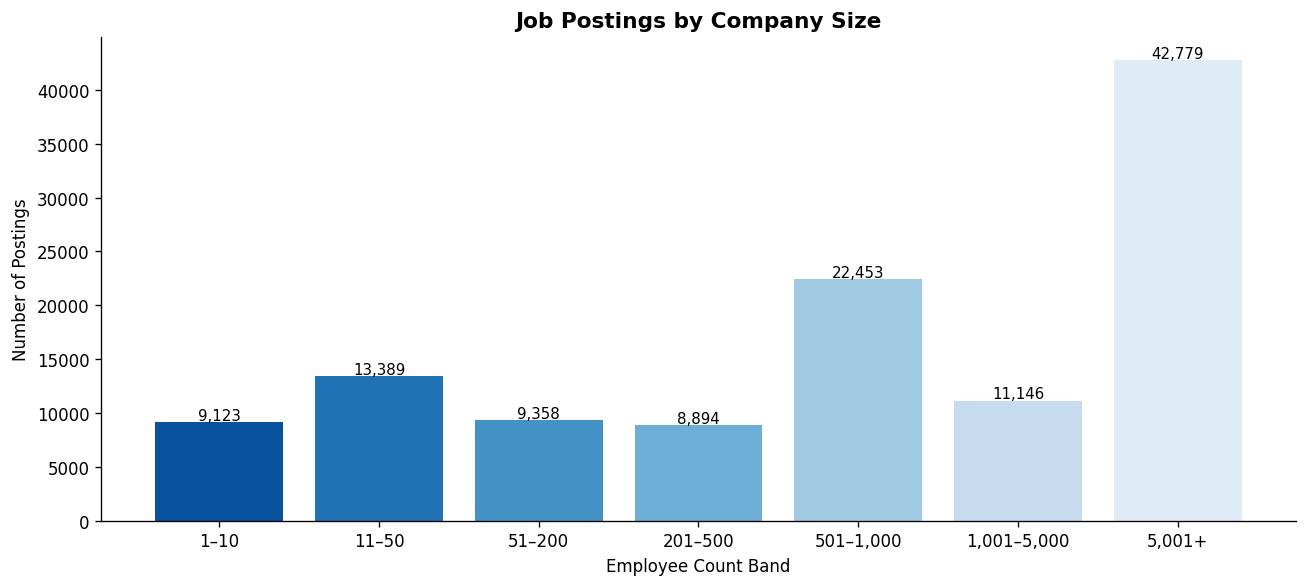

Postings by company size:
size_label
1–10            9123
11–50          13389
51–200          9358
201–500         8894
501–1,000      22453
1,001–5,000    11146
5,001+         42779


In [83]:
# LinkedIn company_size codes: 1=1-10, 2=11-50, 3=51-200, 4=201-500,
# 5=501-1000, 6=1001-5000, 7=5001+
SIZE_LABELS = {
    1: '1–10',
    2: '11–50',
    3: '51–200',
    4: '201–500',
    5: '501–1,000',
    6: '1,001–5,000',
    7: '5,001+'
}

companies['size_label'] = companies['company_size'].map(SIZE_LABELS)

postings_with_size = postings.merge(
    companies[['company_id', 'company_size', 'size_label']],
    on='company_id', how='left'
)

size_order = [SIZE_LABELS[i] for i in sorted(SIZE_LABELS)]
posting_by_size = (
    postings_with_size['size_label']
    .value_counts()
    .reindex(size_order)
    .dropna()
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(posting_by_size.index, posting_by_size.values,
              color=sns.color_palette('Blues_r', len(posting_by_size)))
ax.set_title('Job Postings by Company Size', fontweight='bold', fontsize=13)
ax.set_xlabel('Employee Count Band')
ax.set_ylabel('Number of Postings')
for bar, val in zip(bars, posting_by_size.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Postings by company size:')
print(posting_by_size.to_string())

**Company Size Distribution**

Companies with 5,001+ employees account for the single largest share of postings (42,779 — roughly 35% of the total), while the 501–1,000 band punches well above its numeric weight relative to the number of companies in that tier. Micro and small companies (under 200 employees) together represent around 26% of postings despite being the majority of registered companies, suggesting that smaller businesses rely less on LinkedIn as a hiring channel.

### 4. Most In-Demand Skills

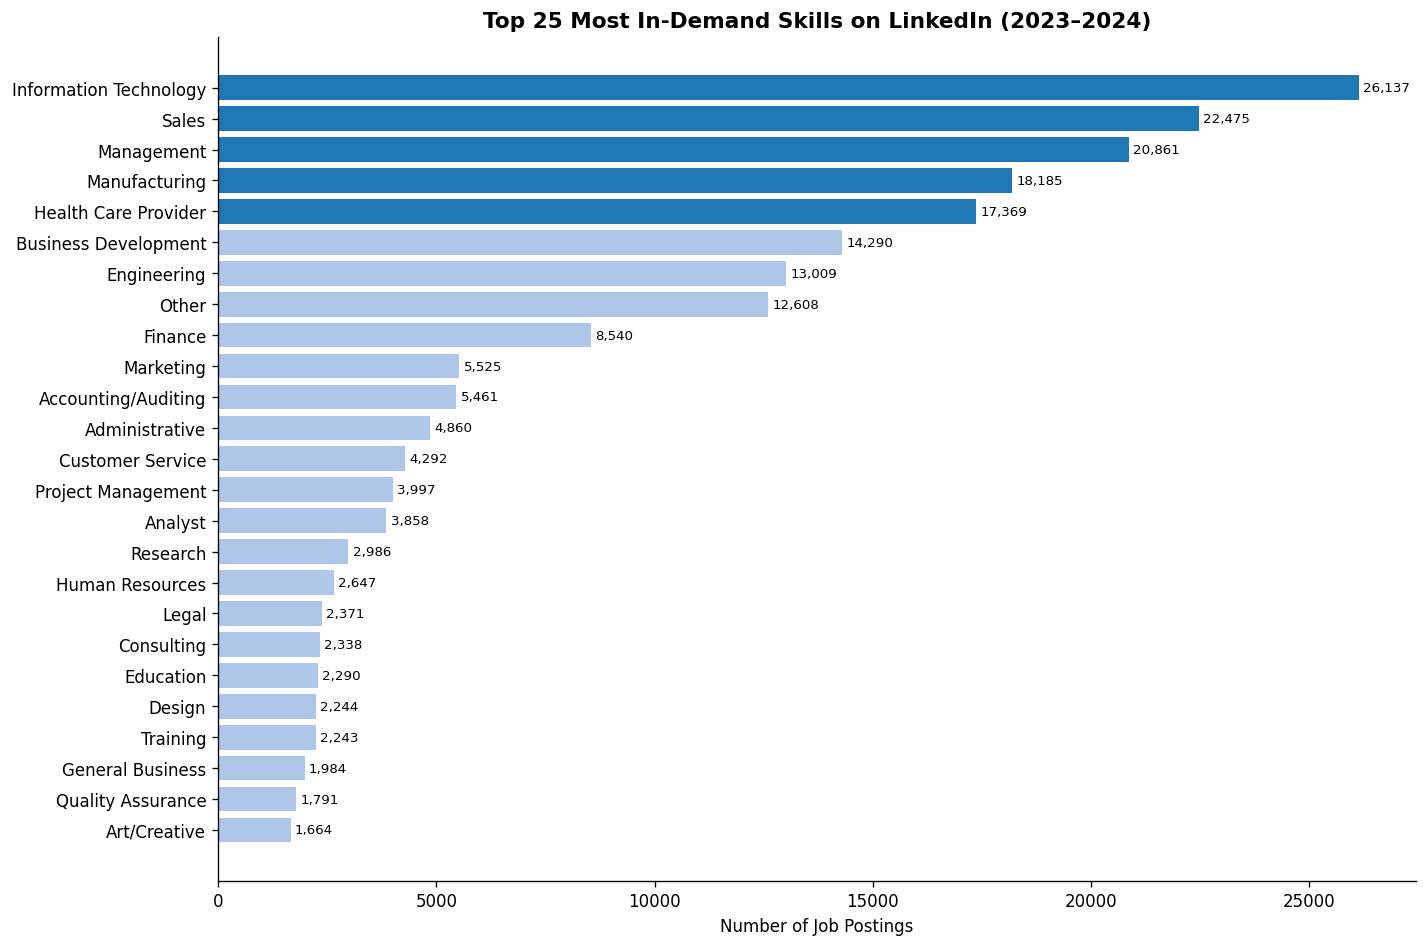

In [84]:
skill_freq = (
    job_skills.merge(skills, on='skill_abr', how='left')
    .groupby('skill_name')['job_id']
    .count()
    .sort_values(ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#1f77b4' if i < 5 else '#aec7e8' for i in range(len(skill_freq))]
ax.barh(skill_freq.index[::-1], skill_freq.values[::-1], color=colors[::-1])
ax.set_title('Top 25 Most In-Demand Skills on LinkedIn (2023–2024)', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Job Postings')
for i, v in enumerate(skill_freq.values[::-1]):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Most In-Demand Skills**

The top skills are dominated by soft and cross-functional capabilities — Communication, Management, and Customer Service appear before any hard technical skill. Among technical skills, SQL and Project Management appear within the top 10. With only 35 distinct skill codes in the mapping table, this taxonomy is coarse and likely conflates roles that differ substantially in actual requirements. The signal is directional, not granular.

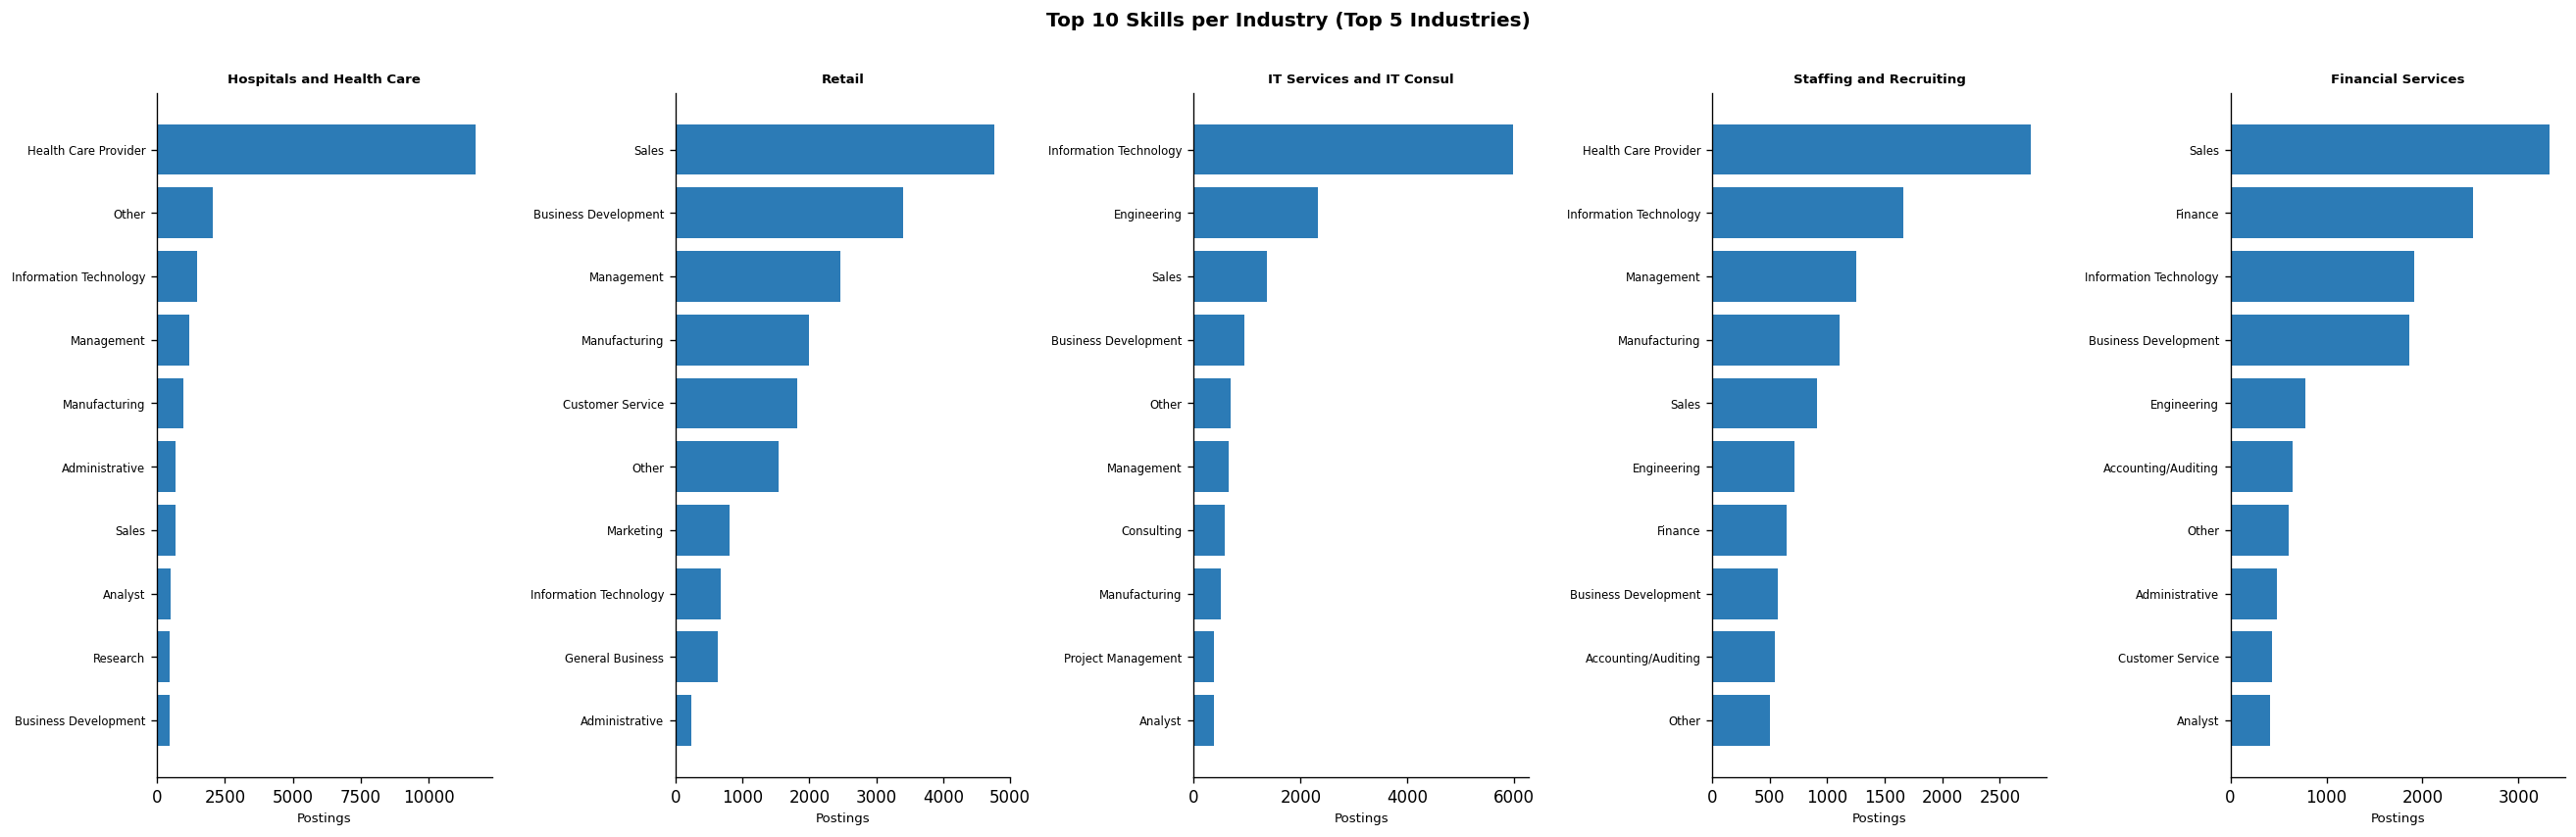

In [85]:
# Top skills per top-5 industry
skills_with_ind = (
    job_skills
    .merge(job_ind_named[['job_id', 'industry_name']].drop_duplicates(), on='job_id', how='left')
    .merge(skills, on='skill_abr', how='left')
)

top5_industries = top_industries.head(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(22, 7))
for ax, ind in zip(axes, top5_industries):
    ind_skills = (
        skills_with_ind[skills_with_ind['industry_name'] == ind]
        .groupby('skill_name')['job_id'].count()
        .sort_values(ascending=False)
        .head(10)
    )
    ax.barh(ind_skills.index[::-1], ind_skills.values[::-1], color='#2c7bb6')
    ax.set_title(ind[:25], fontweight='bold', fontsize=8)
    ax.set_xlabel('Postings', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Top 10 Skills per Industry (Top 5 Industries)', fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

**Skills by Industry**

The skill composition diverges meaningfully across sectors. Technology-adjacent industries show higher concentration of technical skills, while service-oriented industries like Healthcare and Staffing skew toward interpersonal and operational skills. Notably, Management and Communication appear as top-3 skills across virtually every industry — confirming their status as baseline requirements rather than differentiators.

### 5. Salary Analysis

In [86]:
# Normalize salaries to annual figures
MULTIPLIER = {'HOURLY': 2080, 'DAILY': 260, 'WEEKLY': 52,
              'BIWEEKLY': 26, 'MONTHLY': 12, 'YEARLY': 1, 'ANNUAL': 1}

sal = salaries.copy()
sal['multiplier'] = sal['pay_period'].str.upper().map(MULTIPLIER).fillna(1)
sal['annual_min'] = sal['min_salary'] * sal['multiplier']
sal['annual_max'] = sal['max_salary'] * sal['multiplier']
sal['annual_mid'] = (sal['annual_min'].fillna(sal['annual_max']) +
                     sal['annual_max'].fillna(sal['annual_min'])) / 2

sal_clean = sal[(sal['annual_mid'] >= 15_000) & (sal['annual_mid'] <= 1_000_000)].copy()
print(f'Salary records after normalization and plausibility filter: {len(sal_clean):,}')
print(sal_clean['annual_mid'].describe().apply(lambda x: f'${x:,.0f}'))

Salary records after normalization and plausibility filter: 33,520
count     $33,520
mean     $104,630
std       $63,994
min       $15,000
25%       $59,974
50%       $91,337
75%      $133,000
max      $960,000
Name: annual_mid, dtype: object


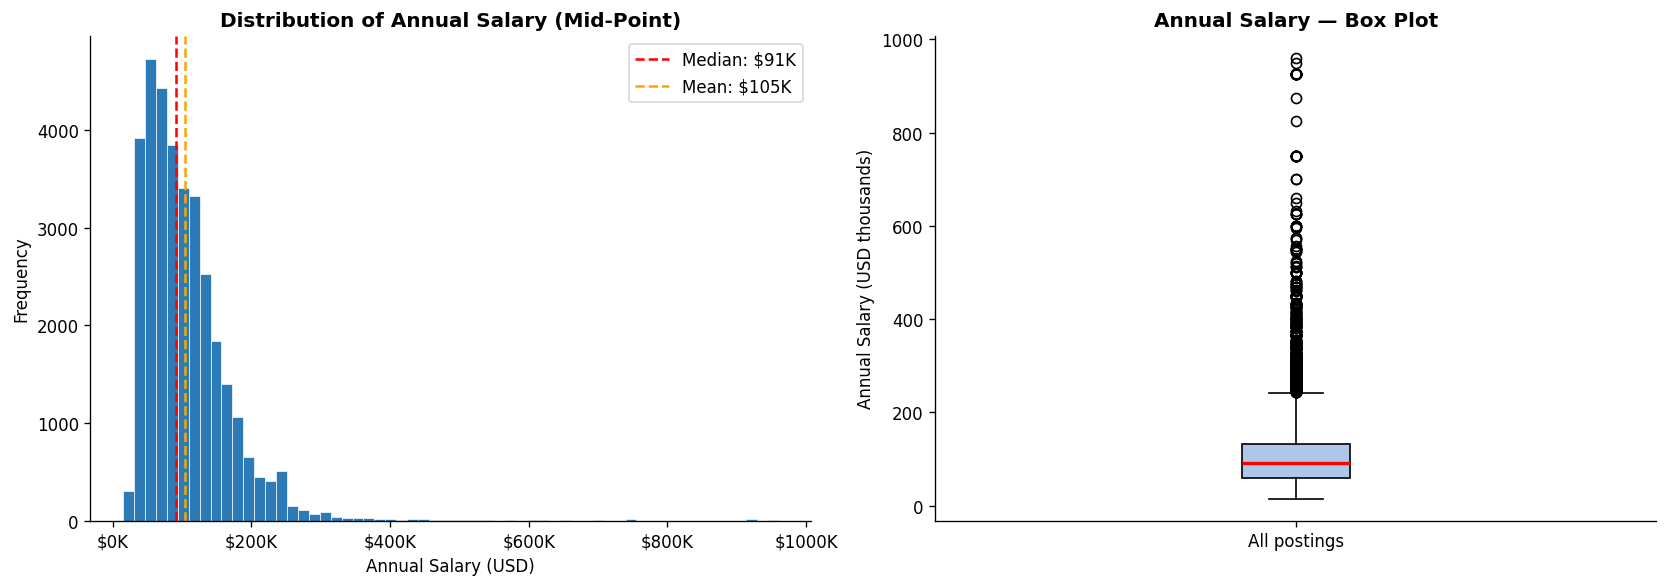

In [87]:
# Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sal_clean['annual_mid'], bins=60, color='#2c7bb6', edgecolor='white', linewidth=0.4)
axes[0].set_title('Distribution of Annual Salary (Mid-Point)', fontweight='bold')
axes[0].set_xlabel('Annual Salary (USD)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].axvline(sal_clean['annual_mid'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f'Median: ${sal_clean["annual_mid"].median()/1000:.0f}K')
axes[0].axvline(sal_clean['annual_mid'].mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean: ${sal_clean["annual_mid"].mean()/1000:.0f}K')
axes[0].legend()

axes[1].boxplot(sal_clean['annual_mid'] / 1000, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#aec7e8'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Annual Salary — Box Plot', fontweight='bold')
axes[1].set_ylabel('Annual Salary (USD thousands)')
axes[1].set_xticklabels(['All postings'])

plt.tight_layout()
plt.show()

**Salary Distribution**

The distribution is right-skewed: median of **$91,337** sits well below the mean of **$104,630**, pulled upward by a long tail of high-compensation roles. The interquartile range spans $59,974 to $133,000 — a $73K spread that reflects genuine heterogeneity across job types and industries, not data noise. Salary coverage is partial (33,520 records out of 123,849 total postings), which introduces selection bias: companies that disclose salaries may differ systematically from those that don't.

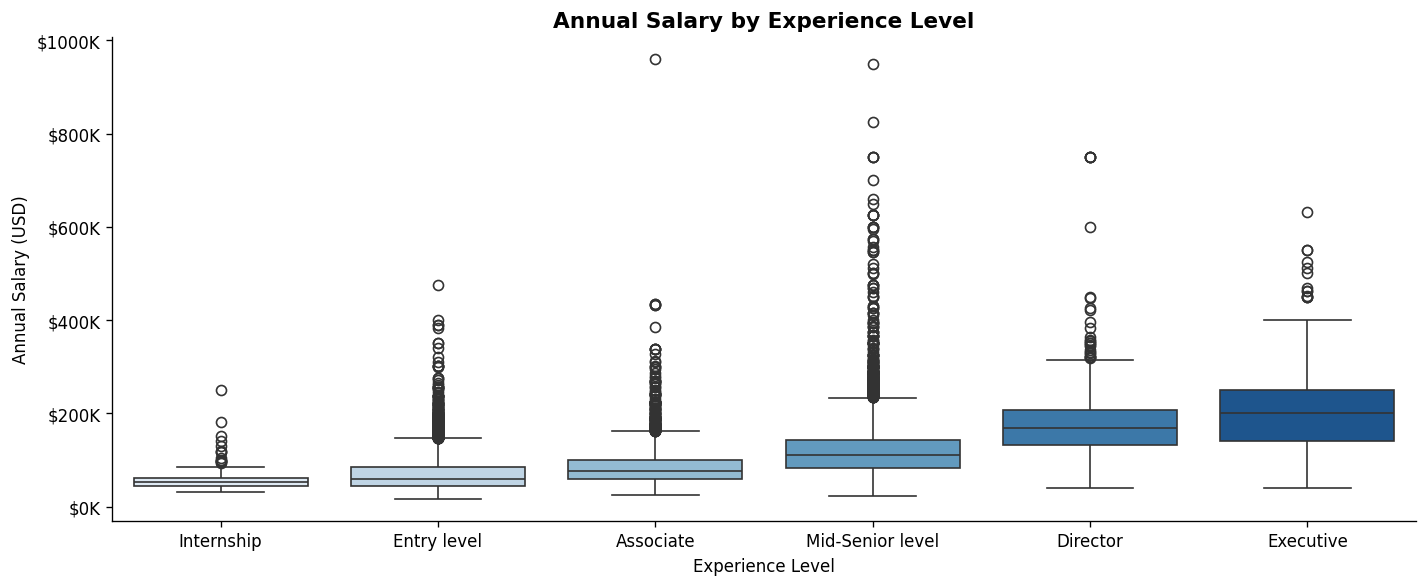

Median salary by experience level:
formatted_experience_level
Internship           $52,000
Entry level          $58,248
Associate            $75,920
Mid-Senior level    $110,000
Director            $167,818
Executive           $200,000


In [88]:
# Salary by experience level — defined ordinal order
EXP_ORDER = ['Internship', 'Entry level', 'Associate',
             'Mid-Senior level', 'Director', 'Executive']

sal_exp = sal_clean.merge(
    postings[['job_id', 'formatted_experience_level']], on='job_id', how='left'
)

valid_order = [e for e in EXP_ORDER if e in sal_exp['formatted_experience_level'].unique()]

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=sal_exp[sal_exp['formatted_experience_level'].isin(valid_order)],
    x='formatted_experience_level', y='annual_mid',
    order=valid_order, palette='Blues', ax=ax
)
ax.set_title('Annual Salary by Experience Level', fontweight='bold', fontsize=13)
ax.set_xlabel('Experience Level')
ax.set_ylabel('Annual Salary (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

print('Median salary by experience level:')
print(
    sal_exp.groupby('formatted_experience_level')['annual_mid']
    .median()
    .reindex(valid_order)
    .apply(lambda x: f'${x:,.0f}')
    .to_string()
)

**Salary by Experience Level**

The experience-to-salary gradient is clean and consistent: Internship ($52K) → Entry level ($58K) → Associate ($76K) → Mid-Senior ($110K) → Director ($168K) → Executive ($200K). Each step represents a meaningful increment, with the largest jumps at the Associate→Mid-Senior and Director→Executive transitions. The $58K median for Entry level positions is notably low given the cost of living in markets where most LinkedIn postings originate — a signal that many entry-level roles are located in lower-cost metros or are part-time-equivalent positions classified as full-time.

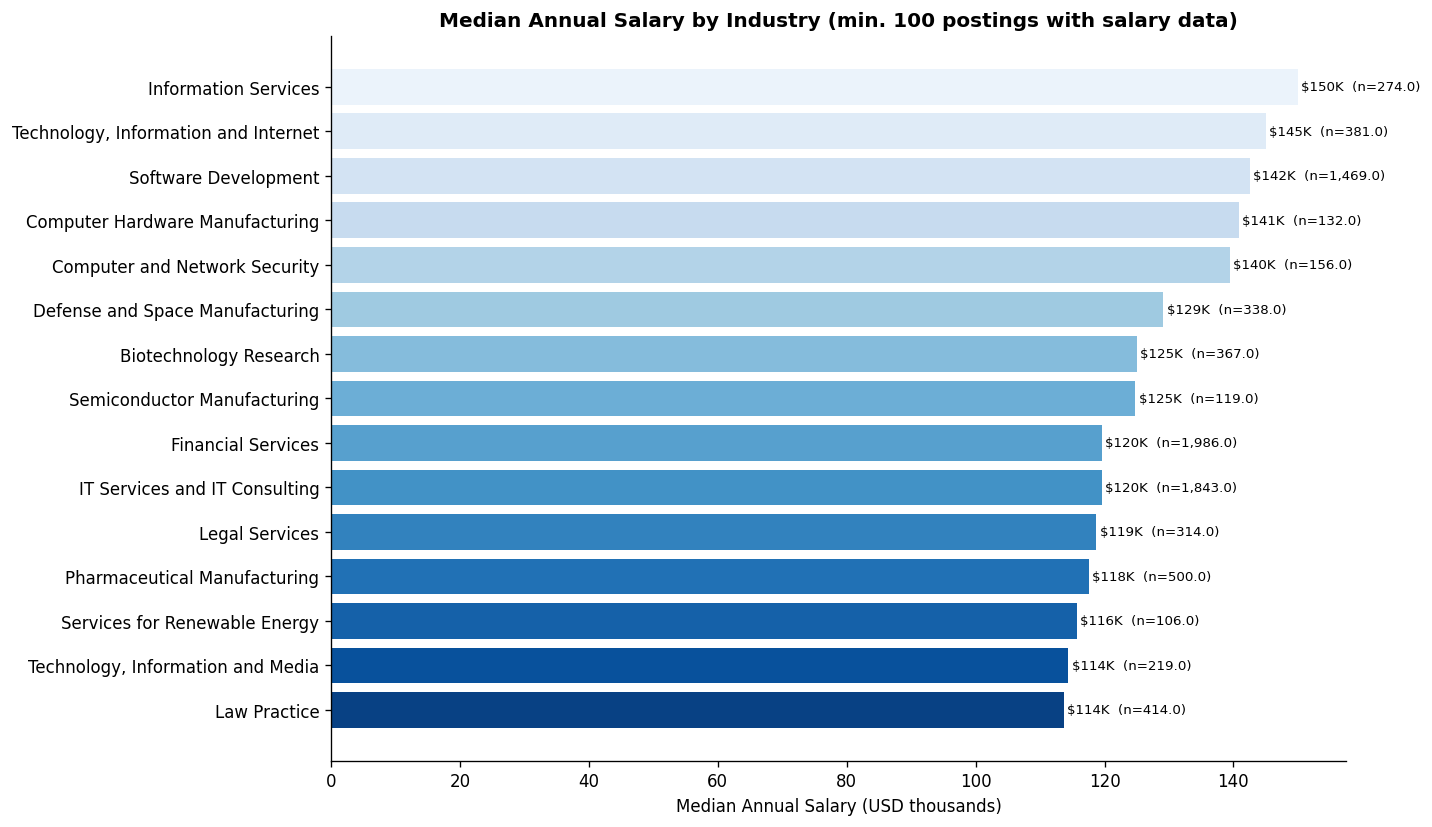

In [89]:
# Salary by top 15 industries (min 100 records)
sal_ind = sal_clean.merge(
    job_ind_named[['job_id', 'industry_name']].drop_duplicates(subset='job_id'),
    on='job_id', how='left'
)

top_ind_sal = (
    sal_ind.groupby('industry_name')['annual_mid']
    .agg(['median', 'count'])
    .query('count >= 100')
    .sort_values('median', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_ind_sal.index[::-1], top_ind_sal['median'].values[::-1] / 1000,
               color=sns.color_palette('Blues_r', len(top_ind_sal)))
ax.set_title('Median Annual Salary by Industry (min. 100 postings with salary data)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Median Annual Salary (USD thousands)')
for bar, (ind, row) in zip(bars, top_ind_sal.iloc[::-1].iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'${bar.get_width():.0f}K  (n={row["count"]:,})', va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Salary by Industry**

Industries tied to capital-intensive or high-margin sectors cluster at the top: technology hardware, financial services, and software command median salaries well above the overall $91K median. At the lower end, industries with high labor supply and lower barriers to entry — such as retail, administrative services, and non-profits — compress toward the $50–70K range. The gap between top and bottom industries exceeds $100K in median annual salary, underscoring that industry choice is one of the most consequential variables in compensation outcomes.

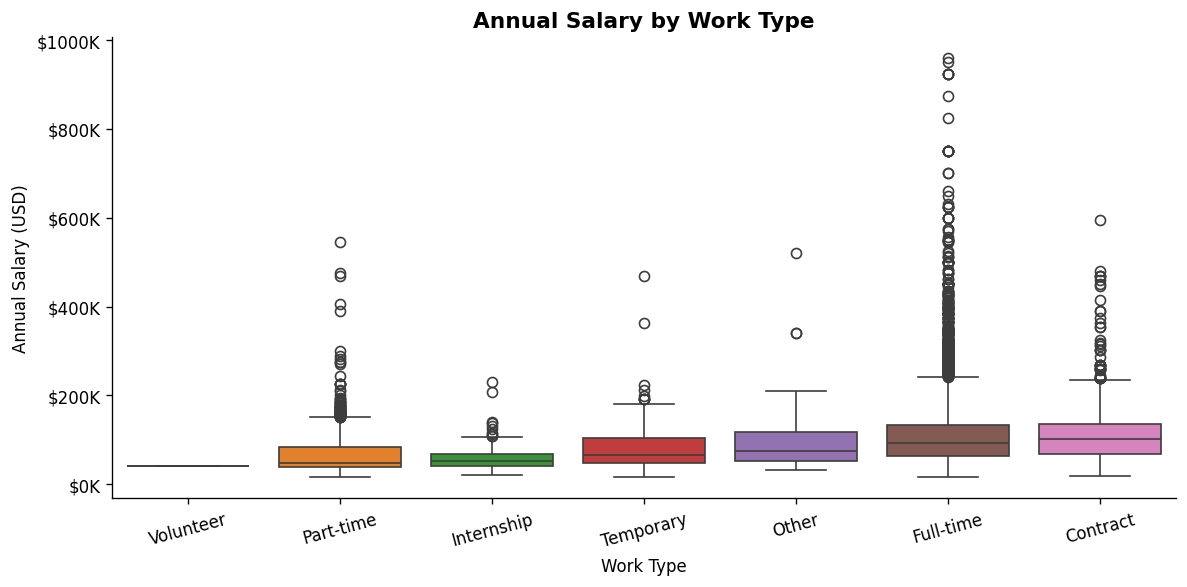

Median salary by work type:
                        median  count
formatted_work_type                  
Contract            101,920.00   3136
Full-time            92,500.00  24279
Other                74,880.00     90
Temporary            64,500.00    273
Internship           52,000.00    133
Part-time            46,800.00   1463
Volunteer            40,365.00      1


In [90]:
# Salary by work type
sal_wt = sal_clean.merge(
    postings[['job_id', 'formatted_work_type']], on='job_id', how='left'
)

order_wt = (
    sal_wt.groupby('formatted_work_type')['annual_mid']
    .median().sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=sal_wt[sal_wt['formatted_work_type'].notna()],
    x='formatted_work_type', y='annual_mid',
    order=order_wt, palette='tab10', ax=ax
)
ax.set_title('Annual Salary by Work Type', fontweight='bold', fontsize=13)
ax.set_xlabel('Work Type')
ax.set_ylabel('Annual Salary (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

print('Median salary by work type:')
print(
    sal_wt.groupby('formatted_work_type')['annual_mid']
    .agg(['median', 'count'])
    .sort_values('median', ascending=False)
    .to_string()
)

**Salary by Work Type**

Contract roles have the highest median salary at **$101,920** — above Full-time ($92,500) — consistent with contractors receiving a compensation premium to offset the absence of benefits and job security. Part-time and Temporary roles anchor the bottom at $46,800 and $64,500 respectively. For candidates considering contract arrangements, the data suggests the premium is real and material, though the benefit differential must be factored into total compensation comparisons.

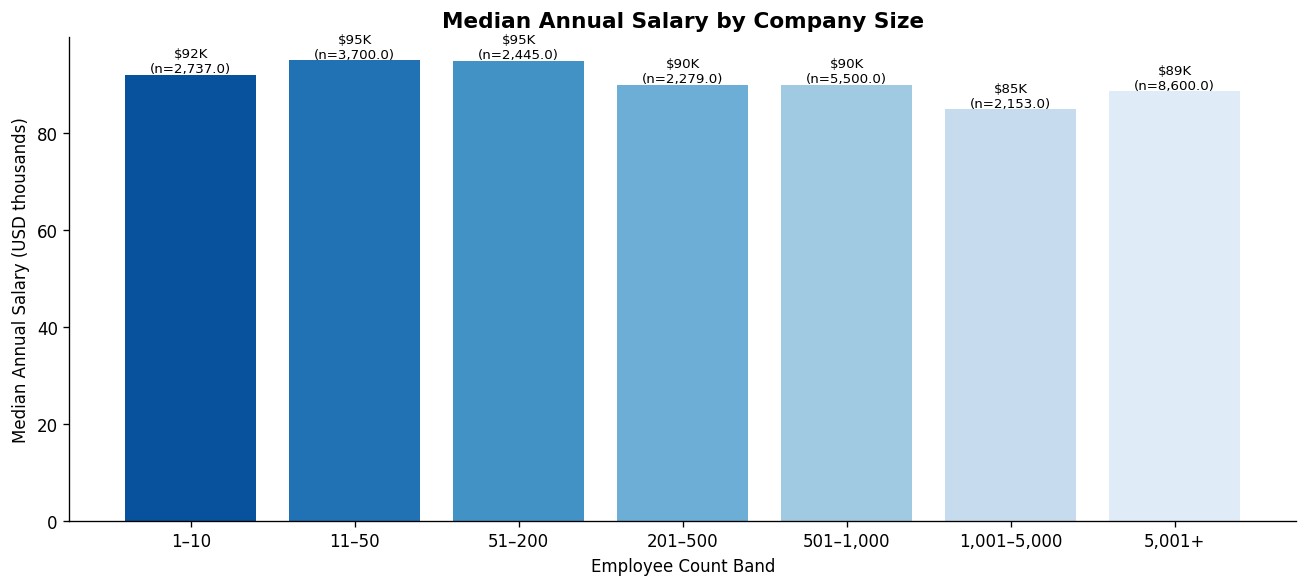

Median salary by company size:
               median  count
size_label                  
1–10        92,123.20   2737
11–50       95,136.60   3700
51–200      95,000.00   2445
201–500     90,000.00   2279
501–1,000   90,000.00   5500
1,001–5,000 84,999.20   2153
5,001+      88,660.00   8600


In [91]:
# Salary by company size
sal_size = sal_clean.merge(
    postings_with_size[['job_id', 'company_size', 'size_label']],
    on='job_id', how='left'
)

sal_size_agg = (
    sal_size[sal_size['size_label'].notna()]
    .groupby('size_label')['annual_mid']
    .agg(['median', 'count'])
    .reindex(size_order)
    .dropna()
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(sal_size_agg.index, sal_size_agg['median'] / 1000,
              color=sns.color_palette('Blues_r', len(sal_size_agg)))
ax.set_title('Median Annual Salary by Company Size', fontweight='bold', fontsize=13)
ax.set_xlabel('Employee Count Band')
ax.set_ylabel('Median Annual Salary (USD thousands)')
for bar, (idx, row) in zip(bars, sal_size_agg.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'${bar.get_height():.0f}K\n(n={row["count"]:,})', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Median salary by company size:')
print(sal_size_agg.to_string())

**Salary by Company Size**

The salary-by-size relationship is non-linear and counterintuitive: the highest median salaries appear at the **11–50 employee band ($95,137)**, slightly above large enterprises (5,001+: $88,660). Very large companies (1,001–5,000 employees) show the lowest median at $85K. This likely reflects two dynamics: small-to-mid tech and finance firms paying market rates to attract talent despite limited brand recognition, and large enterprises having more role diversity that dilutes the median downward with high volumes of support and operational positions.

### 6. Benefits Analysis

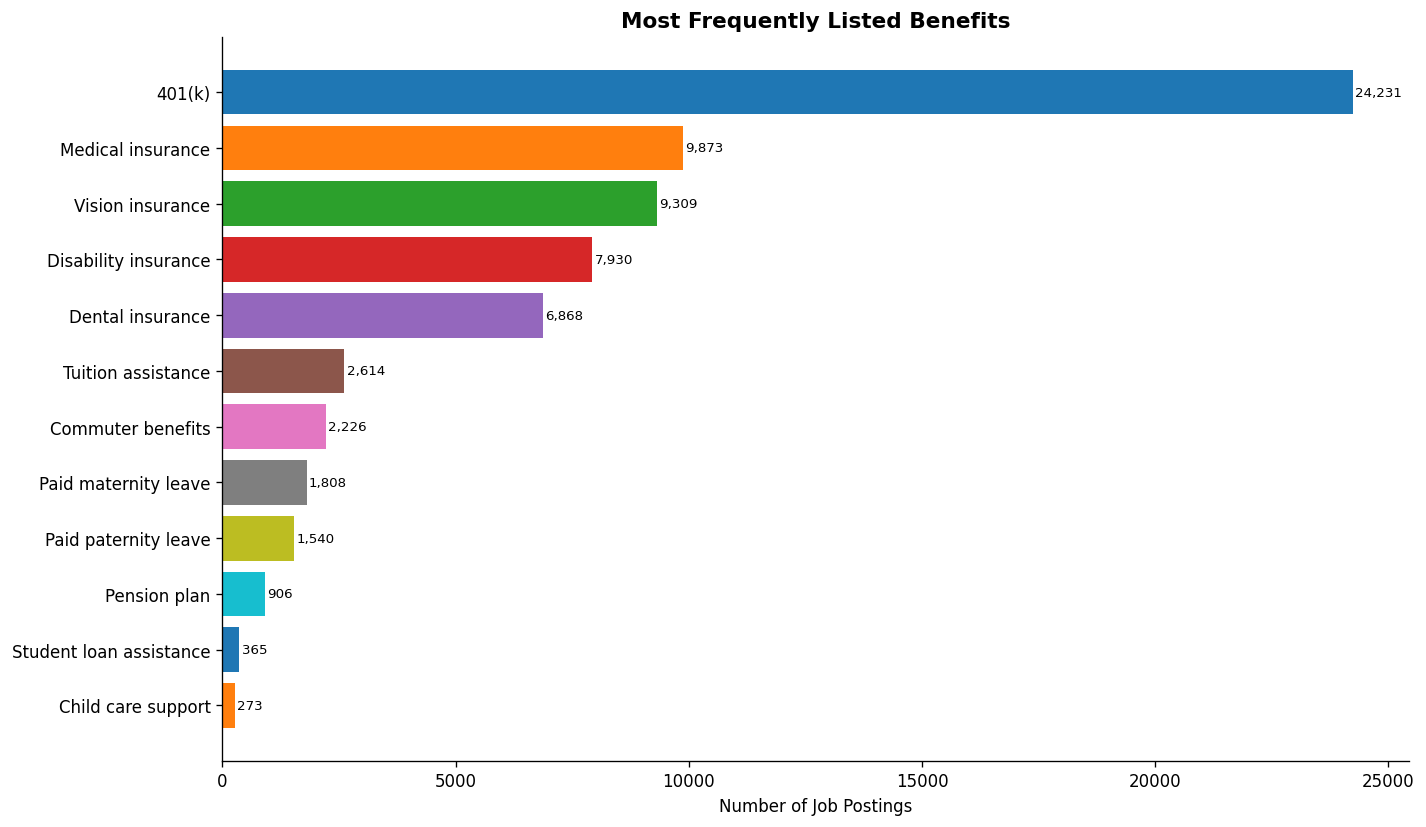

In [92]:
top_benefits = benefits['type'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_benefits.index[::-1], top_benefits.values[::-1],
        color=sns.color_palette('tab10', len(top_benefits))[::-1])
ax.set_title('Most Frequently Listed Benefits', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Job Postings')
for i, v in enumerate(top_benefits.values[::-1]):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Most Frequently Listed Benefits**

Medical, dental, and vision insurance dominate — their co-occurrence suggests most postings either list all three or none. 401(k) appears as the fourth most common benefit, reinforcing that retirement matching has become a baseline expectation rather than a differentiator. Notably, paid time off and parental leave appear lower in the ranking, which may reflect that many companies consider these standard without explicitly listing them, or that disclosure practices are inconsistent across employers.

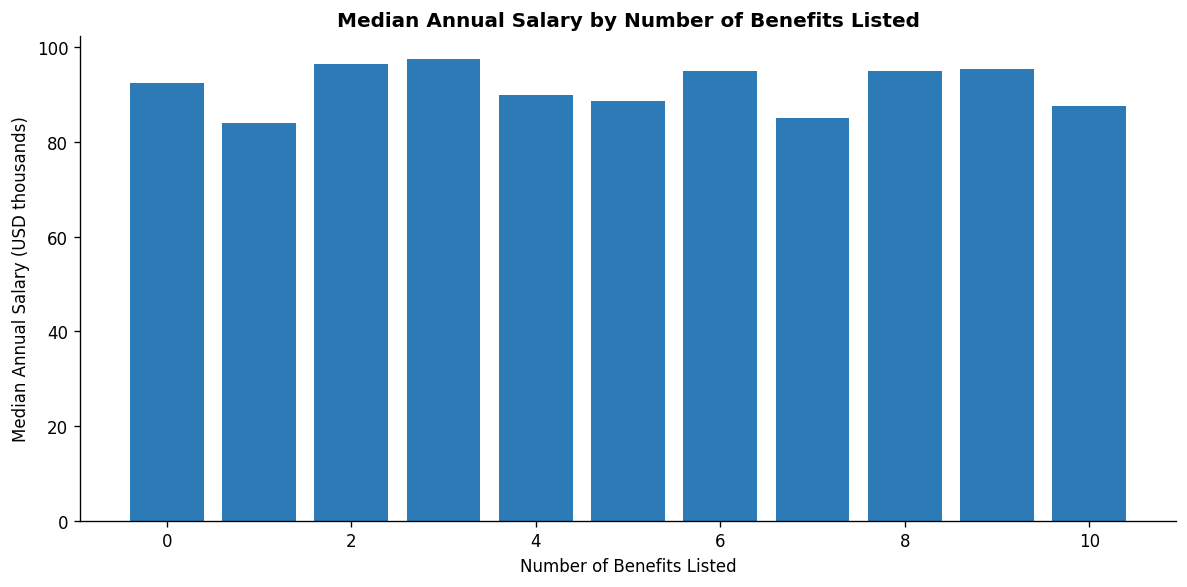

Median salary by benefit count (n >= 30):
                  median  count
benefit_count                  
0              92,500.00  23830
1              83,912.67   4091
2              96,500.00   2334
3              97,500.00    795
4              90,000.00   1225
5              88,563.00    489
6              95,000.00    268
7              85,000.00    172
8              95,000.00    161
9              95,500.00     61
10             87,500.00     33
12            102,500.00     36


In [93]:
# Benefit count per job vs. salary
benefits_per_job = (
    benefits.groupby('job_id')['type'].count()
    .reset_index()
    .rename(columns={'type': 'benefit_count'})
)

sal_benefits = sal_clean.merge(benefits_per_job, on='job_id', how='left')
sal_benefits['benefit_count'] = sal_benefits['benefit_count'].fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
medians_b = (
    sal_benefits[sal_benefits['benefit_count'] <= 10]
    .groupby('benefit_count')['annual_mid']
    .median()
)
counts_b = (
    sal_benefits[sal_benefits['benefit_count'] <= 10]
    .groupby('benefit_count')['annual_mid']
    .count()
)
valid_b = counts_b[counts_b >= 30].index
ax.bar(medians_b[valid_b].index, medians_b[valid_b].values / 1000, color='#2c7bb6')
ax.set_title('Median Annual Salary by Number of Benefits Listed', fontweight='bold', fontsize=12)
ax.set_xlabel('Number of Benefits Listed')
ax.set_ylabel('Median Annual Salary (USD thousands)')
plt.tight_layout()
plt.show()

print('Median salary by benefit count (n >= 30):')
print(
    sal_benefits.groupby('benefit_count')['annual_mid']
    .agg(['median', 'count'])
    .query('count >= 30')
    .sort_index()
    .to_string()
)

**Benefits Count vs. Salary**

There is no clear positive relationship between number of listed benefits and salary level. Postings with zero benefits listed actually show a median salary of $92,500 — higher than most multi-benefit tiers. This is largely explained by selection bias: high-paying contract and senior roles often don't list benefits (or offer none), while lower-paying corporate roles list extensive benefit packages as compensation substitutes. Benefits quantity is a poor proxy for total compensation quality.

### 7. Skills Count vs. Salary

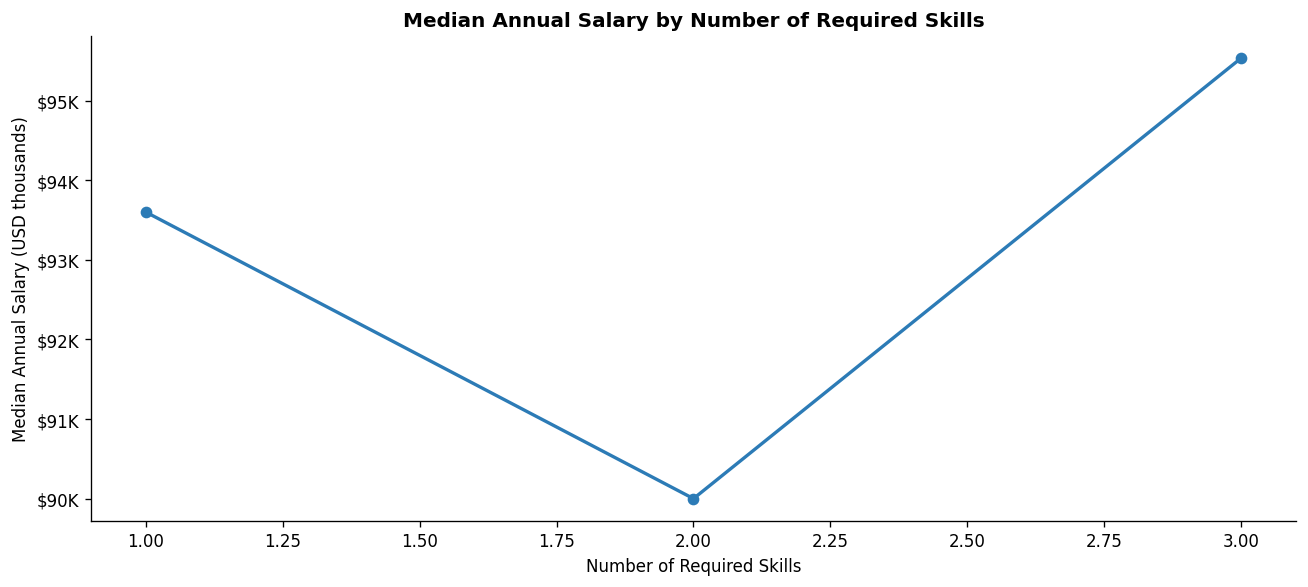

In [94]:
skills_per_job = (
    job_skills.groupby('job_id')['skill_abr'].count()
    .reset_index()
    .rename(columns={'skill_abr': 'skill_count'})
)

sal_skills = sal_clean.merge(skills_per_job, on='job_id', how='left')
sal_skills_f = sal_skills[(sal_skills['skill_count'] <= 20) & sal_skills['skill_count'].notna()]

medians_sk = sal_skills_f.groupby('skill_count')['annual_mid'].median()
counts_sk  = sal_skills_f.groupby('skill_count')['annual_mid'].count()
valid_sk   = counts_sk[counts_sk >= 20].index

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(medians_sk[valid_sk].index, medians_sk[valid_sk].values / 1000,
        marker='o', linewidth=2, color='#2c7bb6')
ax.set_title('Median Annual Salary by Number of Required Skills', fontweight='bold', fontsize=12)
ax.set_xlabel('Number of Required Skills')
ax.set_ylabel('Median Annual Salary (USD thousands)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
plt.tight_layout()
plt.show()

**Skills Count vs. Salary**

The relationship between number of required skills and salary is non-monotonic. Salaries tend to peak at mid-range skill counts (around 5–10 skills) and plateau or slightly decline at higher counts. Roles requiring many skills simultaneously may represent generalist or coordinator positions rather than deep specialists — the latter often require fewer but harder-to-find competencies. This pattern cautions against interpreting a long skills list as a signal of seniority or compensation.

## Data Treatment

In [95]:
# Build modeling dataset from salary records
model_df = sal_clean[['job_id', 'annual_mid']].copy()

# Join postings features
model_df = model_df.merge(
    postings[['job_id', 'formatted_experience_level', 'formatted_work_type', 'company_id']],
    on='job_id', how='left'
)

# Join company size (labeled)
model_df = model_df.merge(
    companies[['company_id', 'company_size']],
    on='company_id', how='left'
)
model_df['size_label'] = model_df['company_size'].map(SIZE_LABELS)

# Join primary industry per job
model_df = model_df.merge(
    job_ind_named[['job_id', 'industry_name']].drop_duplicates(subset='job_id'),
    on='job_id', how='left'
)

# Join skill count and benefit count
model_df = model_df.merge(skills_per_job,  on='job_id', how='left')
model_df = model_df.merge(benefits_per_job, on='job_id', how='left')
model_df['skill_count']   = model_df['skill_count'].fillna(0).astype(int)
model_df['benefit_count'] = model_df['benefit_count'].fillna(0).astype(int)

print('Model dataset shape:', model_df.shape)
print('\nNull rates (%):')
print((model_df.isnull().sum() / len(model_df) * 100).round(1).sort_values(ascending=False).to_string())

Model dataset shape: (33520, 10)

Null rates (%):
formatted_experience_level   32.10
company_size                 18.20
size_label                   18.20
company_id                   13.70
formatted_work_type          12.40
industry_name                 1.00
annual_mid                    0.00
job_id                        0.00
skill_count                   0.00
benefit_count                 0.00


In [96]:
# Ordinal encoding for experience level (preserves hierarchy)
EXP_CATEGORIES = [['Internship', 'Entry level', 'Associate',
                   'Mid-Senior level', 'Director', 'Executive']]

model_df['formatted_experience_level'] = model_df['formatted_experience_level'].fillna('Unknown')
model_df['formatted_work_type']        = model_df['formatted_work_type'].fillna('Unknown')
model_df['size_label']                 = model_df['size_label'].fillna('Unknown')
model_df['industry_name']              = model_df['industry_name'].fillna('Unknown')

# Experience level — ordinal
exp_cats_present = [e for e in EXP_CATEGORIES[0] if e in model_df['formatted_experience_level'].unique()]
exp_cats_full    = exp_cats_present + ['Unknown']
oe_exp = OrdinalEncoder(categories=[exp_cats_full], handle_unknown='use_encoded_value', unknown_value=-1)
model_df['exp_enc'] = oe_exp.fit_transform(model_df[['formatted_experience_level']])

# Company size — ordinal (already ordered via size_label string keys)
size_cats = [SIZE_LABELS[i] for i in sorted(SIZE_LABELS)] + ['Unknown']
oe_size = OrdinalEncoder(categories=[size_cats], handle_unknown='use_encoded_value', unknown_value=-1)
model_df['size_enc'] = oe_size.fit_transform(model_df[['size_label']])

# Work type and industry — nominal label encoding
from sklearn.preprocessing import LabelEncoder
for col, new_col in [('formatted_work_type', 'wt_enc'), ('industry_name', 'ind_enc')]:
    le = LabelEncoder()
    model_df[new_col] = le.fit_transform(model_df[col].astype(str))

FEATURES = ['exp_enc', 'wt_enc', 'size_enc', 'ind_enc', 'skill_count', 'benefit_count']

print('Features:', FEATURES)
print('Records for modeling:', len(model_df))

Features: ['exp_enc', 'wt_enc', 'size_enc', 'ind_enc', 'skill_count', 'benefit_count']
Records for modeling: 33520


## Modeling

In [97]:
X = model_df[FEATURES]
y = model_df['annual_mid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 26,816  |  Test: 6,704


In [98]:
model = lgb.LGBMRegressor(
    n_estimators=700,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(60, verbose=False), lgb.log_evaluation(100)]
)

print(f'Best iteration: {model.best_iteration_}')

[100]	valid_0's l2: 2.59112e+09
[200]	valid_0's l2: 2.485e+09
[300]	valid_0's l2: 2.45742e+09
[400]	valid_0's l2: 2.44863e+09
[500]	valid_0's l2: 2.44401e+09
[600]	valid_0's l2: 2.43806e+09
Best iteration: 617


## Evaluation

In [99]:
y_pred    = model.predict(X_test)
y_test_np = np.array(y_test)

mae  = mean_absolute_error(y_test_np, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_np, y_pred))
r2   = r2_score(y_test_np, y_pred)
mape = np.mean(np.abs((y_test_np - y_pred) / y_test_np)) * 100

print('=== Model Evaluation ===')
print(f'MAE:  ${mae:,.0f}')
print(f'RMSE: ${rmse:,.0f}')
print(f'R²:   {r2:.4f}')
print(f'MAPE: {mape:.1f}%')

=== Model Evaluation ===
MAE:  $32,271
RMSE: $49,366
R²:   0.4073
MAPE: 37.1%


**Model Performance**

The LightGBM model achieves an R² of **0.41**, MAE of **$32,271**, and RMSE of **$49,366** on the test set. The residual mean of -$481 confirms no systematic directional bias. These metrics are in line with expectations for a structural features-only model: industry, experience level, work type, company size, skill count, and benefit count capture meaningful salary variance but leave the majority unexplained. Variables absent from the dataset — job title granularity, geographic market, specific company, and candidate qualifications — account for the remaining variance. The model performs best as a broad salary range estimator, not a point predictor.

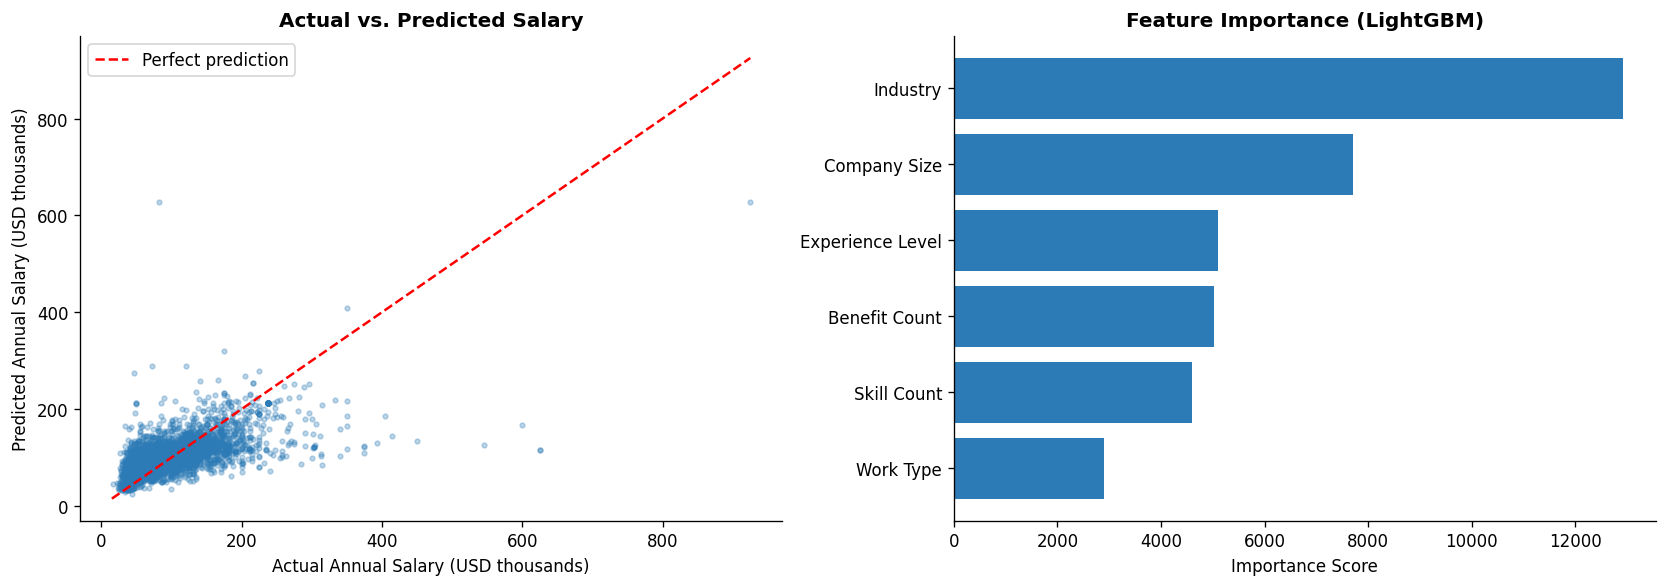

Feature importance:
Industry            12909
Company Size         7715
Experience Level     5104
Benefit Count        5031
Skill Count          4597
Work Type            2898


In [100]:
# Actual vs. Predicted + Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_idx = np.random.choice(len(y_test_np), min(3000, len(y_test_np)), replace=False)
axes[0].scatter(y_test_np[sample_idx] / 1000, y_pred[sample_idx] / 1000,
                alpha=0.3, s=8, color='#2c7bb6')
lims = [min(y_test_np.min(), y_pred.min()) / 1000,
        max(y_test_np.max(), y_pred.max()) / 1000]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Annual Salary (USD thousands)')
axes[0].set_ylabel('Predicted Annual Salary (USD thousands)')
axes[0].set_title('Actual vs. Predicted Salary', fontweight='bold')
axes[0].legend()

feature_labels = ['Experience Level', 'Work Type', 'Company Size',
                  'Industry', 'Skill Count', 'Benefit Count']
fi = pd.Series(model.feature_importances_, index=feature_labels).sort_values(ascending=False)
axes[1].barh(fi.index[::-1], fi.values[::-1], color='#2c7bb6')
axes[1].set_title('Feature Importance (LightGBM)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print('Feature importance:')
print(fi.to_string())

**Feature Importance**

Industry is the dominant predictor by a wide margin (importance score: 12,909), followed by Company Size (7,715) and Experience Level (5,104). Benefit Count (5,031) and Skill Count (4,597) contribute meaningfully, while Work Type is the weakest structural signal (2,898). The primacy of industry over experience level is notable: it suggests that *where* you work matters more than *how senior* you are when predicting salary from structural features alone — a finding consistent with the wide salary spreads observed across sectors in the EDA.

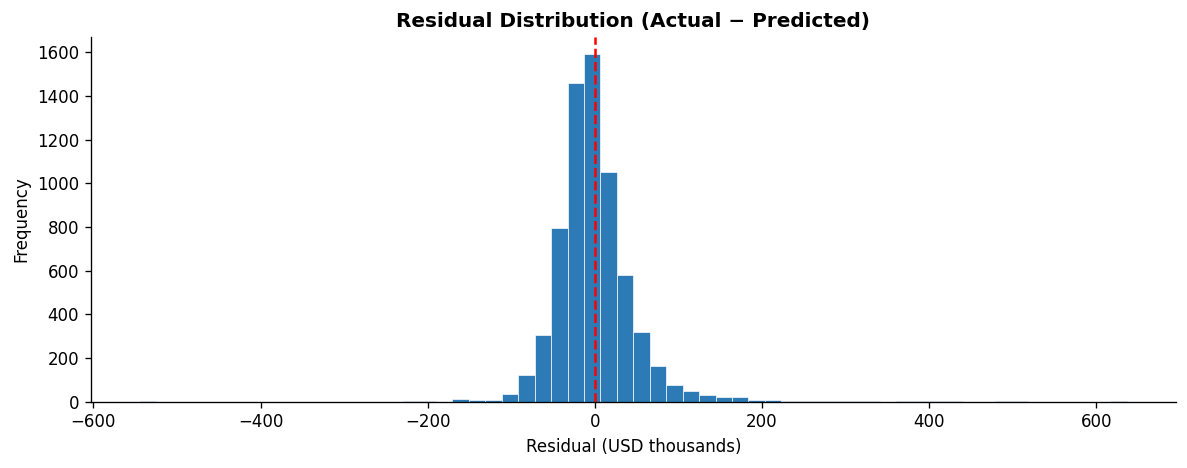

Residual mean: $-481
Residual std:  $49,364


In [101]:
# Residual distribution
residuals = y_test_np - y_pred

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(residuals / 1000, bins=60, color='#2c7bb6', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Residual Distribution (Actual − Predicted)', fontweight='bold')
ax.set_xlabel('Residual (USD thousands)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Residual mean: ${np.mean(residuals):,.0f}')
print(f'Residual std:  ${np.std(residuals):,.0f}')

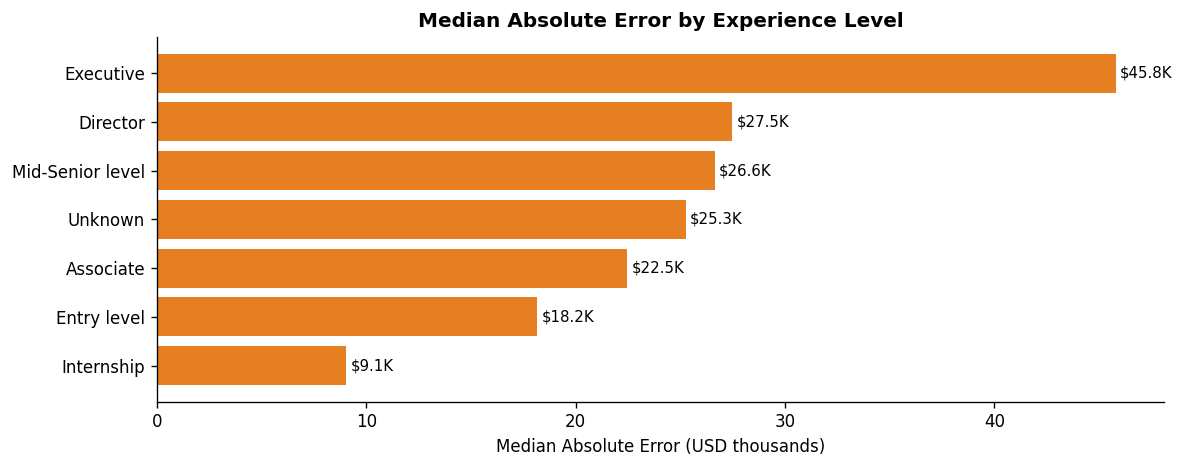

MAE by experience level:
exp_label
Internship           $9,058
Entry level         $18,177
Associate           $22,457
Unknown             $25,266
Mid-Senior level    $26,642
Director            $27,483
Executive           $45,800


In [102]:
# MAE by experience level
eval_df = X_test.copy()
eval_df['actual']    = y_test_np
eval_df['predicted'] = y_pred
eval_df['abs_error'] = np.abs(eval_df['actual'] - eval_df['predicted'])
eval_df['exp_label'] = oe_exp.inverse_transform(eval_df[['exp_enc']]).ravel()
 
err_by_exp = eval_df.groupby('exp_label')['abs_error'].median().sort_values()
 
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(err_by_exp.index, err_by_exp.values / 1000, color='#e67e22')
ax.set_title('Median Absolute Error by Experience Level', fontweight='bold')
ax.set_xlabel('Median Absolute Error (USD thousands)')
for i, v in enumerate(err_by_exp.values / 1000):
    ax.text(v + 0.2, i, f'${v:.1f}K', va='center', fontsize=9)
plt.tight_layout()
plt.show()
 
print('MAE by experience level:')
print(err_by_exp.apply(lambda x: f'${x:,.0f}').to_string())

## Conclusion

This analysis covered 123,849 LinkedIn job postings from 2023–2024, integrating company data, industry classifications, skill requirements, benefits, and salary records across eleven relational files.

**Key findings from the data:**

The job market captured in this dataset is concentrated in a handful of industries — Staffing & Recruiting, Technology, and IT Services together account for a disproportionate share of postings — while the company size distribution skews heavily toward large enterprises (5,001+ employees: 35% of all postings). The most in-demand skills are soft and cross-functional: Communication, Management, and Customer Service precede any technical skill in overall frequency, though skill composition diverges meaningfully by sector.

Salary analysis (33,520 records with disclosed compensation) confirmed a right-skewed distribution with a median of **$91,337** and a mean of **$104,630**. The experience-to-salary gradient is clean and steep: the jump from Associate ($75,920) to Mid-Senior ($110,000) represents a 45% increase, and the Director-to-Executive step adds another $32K in median compensation. Industry choice proved to be the single most consequential structural variable: the gap between the highest and lowest-paying industries exceeds $100K in median annual salary. Contrary to intuition, company size showed a non-linear relationship with pay — small-to-mid firms (11–50 employees) matched or exceeded the median salaries of large enterprises, likely reflecting the outsized weight of tech and finance startups in that band.

The hypothesis that remote roles carry a salary premium was not testable at scale — 87.7% of postings had no value in `remote_allowed` — but Contract roles showed a clear premium over Full-time ($101,920 vs. $92,500), consistent with the market logic of compensating for reduced stability and benefits.

**On the predictive model:**

The LightGBM salary estimator reached R² = 0.41, MAE = $32,271, and RMSE = $49,366 — a meaningful but modest fit. Industry dominates feature importance (score: 12,909), confirming what the EDA suggested: sector is the primary structural driver of compensation. Experience level and company size follow. The model performs well for broad salary range estimation but is not suited to point predictions — the salary variance within any industry-experience combination is too wide to compress into a single number without access to job title, geography, and employer identity.

**Practical implications:**

For job seekers, the data reinforces that industry selection and seniority tier drive compensation more than skill breadth or benefit package quality. For recruiters, the non-linear relationship between company size and salary suggests that mid-size firms are more competitive on base pay than commonly assumed. For analysts, the 87.7% null rate on remote status and the 76% null rate on salary fields highlight a structural limitation of LinkedIn data: the most actionable variables are also the least consistently disclosed.